# 9.2-9.3 混合ガウスモデルとベルヌーイ混合モデル (GMM & BMM)

本ノートブックでは、潜在変数モデルに対する基本的手法である **混合ガウスモデル (GMM)** と **ベルヌーイ混合モデル (BMM)**、およびそのパラメータを反復推定する **EM (Expectation-Maximization) アルゴリズム** を学びます。
最尤推定における分散ゼロ特異点（**PRML Figure 9.7**）、Old Faithful 間欠泉データに対する EM の段階的学習と楕円等高線のフィット過程（**PRML Figure 9.8**）、共分散ゼロ極限における K-means への退化（PRML 9.3.2）、および手書き数字二値データにおけるクラスタ平均プロトタイプの自律的出現（**PRML Figure 9.10**）を完全実装します。

## 9.2 混合ガウスモデルと EM アルゴリズム (PRML Figure 9.8)

### モデルの定式化
$$ p(\mathbf{x}) = \sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_k, \mathbf{\Sigma}_k), \quad \sum_{k=1}^K \pi_k = 1 $$
各データ点 $\mathbf{x}_n$ に対し、どの成分から生成されたかを表す 1-of-K 潜在変数 $\mathbf{z}_n \in \{0, 1\}^K$ を考えます。

### EMアルゴリズム
1. **Eステップ (Expectation)**: 現在のパラメータを用いて事後確率（負担率: Responsibilities）を計算：
   $$ \gamma(z_{nk}) = p(z_{nk} = 1 | \mathbf{x}_n) = \frac{\pi_k \mathcal{N}(\mathbf{x}_n | \boldsymbol{\mu}_k, \mathbf{\Sigma}_k)}{\sum_{j=1}^K \pi_j \mathcal{N}(\mathbf{x}_n | \boldsymbol{\mu}_j, \mathbf{\Sigma}_j)} $$
2. **Mステップ (Maximization)**: 負担率を固定し、完全データの期待対数尤度を最大化：
   $$ N_k = \sum_{n=1}^N \gamma(z_{nk}) $$
   $$ \boldsymbol{\mu}_k^{\mathrm{new}} = \frac{1}{N_k} \sum_{n=1}^N \gamma(z_{nk}) \mathbf{x}_n $$
   $$ \mathbf{\Sigma}_k^{\mathrm{new}} = \frac{1}{N_k} \sum_{n=1}^N \gamma(z_{nk}) (\mathbf{x}_n - \boldsymbol{\mu}_k^{\mathrm{new}})(\mathbf{x}_n - \boldsymbol{\mu}_k^{\mathrm{new}})^{\mathrm{T}} $$
   $$ \pi_k^{\mathrm{new}} = \frac{N_k}{N} $$

Plot saved to: result/fig9_8_gmm_em_faithful_steps.png


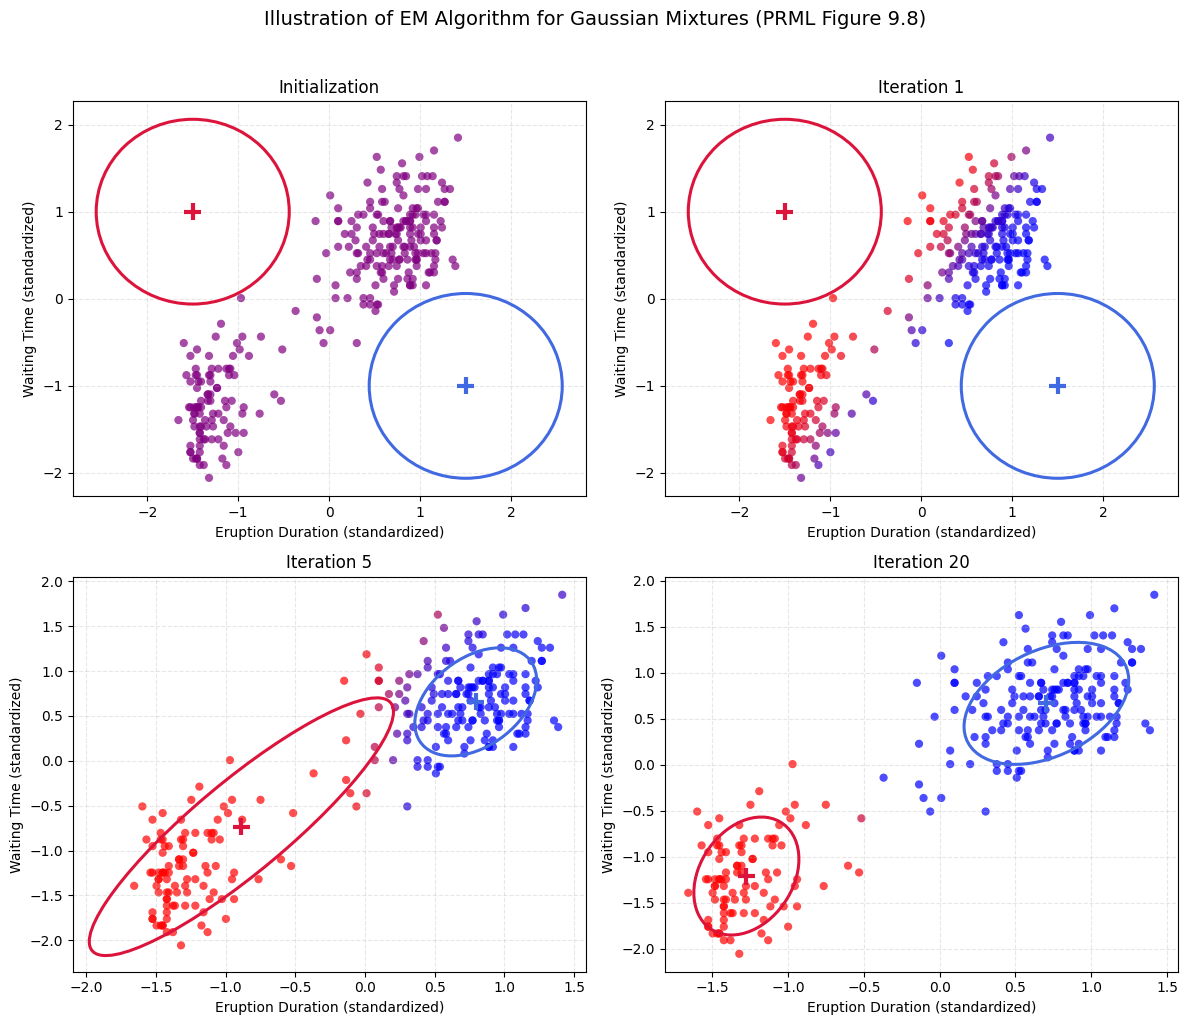

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal
from common.plot_utils import save_plot, setup_style
setup_style()

# 楕円描画ユーティリティ
def plot_gaussian_ellipse(ax, mean, cov, n_std=1.5, color='crimson', lw=2.0):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * n_std * np.sqrt(np.maximum(vals, 1e-8))
    ell = Ellipse(xy=mean, width=w, height=h, angle=theta, edgecolor=color, fc='none', lw=lw, zorder=4)
    ax.add_patch(ell)

# Old Faithful データの準備
df = pd.read_csv('../common/faithful.csv')
X_raw = df[['duration', 'waiting']].values
X = (X_raw - np.mean(X_raw, axis=0)) / np.std(X_raw, axis=0)
N, D = X.shape
K = 2

# PRML Figure 9.8 の初期設定
mu = np.array([[-1.5, 1.0], [1.5, -1.0]])
covs = np.array([np.eye(2) * 0.5, np.eye(2) * 0.5])
weights = np.array([0.5, 0.5])

# スナップショットを記録するイテレーション数: 0 (初期), 1, 5, 20 (収束)
snapshots = {}
snapshots[0] = (mu.copy(), covs.copy(), weights.copy(), np.ones((N, K)) * 0.5)

for iteration in range(1, 21):
    # Eステップ
    densities = np.zeros((N, K))
    for k in range(K):
        densities[:, k] = weights[k] * multivariate_normal.pdf(X, mean=mu[k], cov=covs[k])
    gamma = densities / np.sum(densities, axis=1, keepdims=True)
    
    if iteration in [1, 5, 20]:
        snapshots[iteration] = (mu.copy(), covs.copy(), weights.copy(), gamma.copy())
        
    # Mステップ
    N_k = np.sum(gamma, axis=0)
    weights = N_k / N
    mu = (gamma.T @ X) / N_k[:, np.newaxis]
    for k in range(K):
        diff = X - mu[k]
        covs[k] = (gamma[:, k:k+1] * diff).T @ diff / N_k[k]

# PRML Figure 9.8 のプロット (4つの反復ステージ)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

iter_keys = [0, 1, 5, 20]
for idx, it in enumerate(iter_keys):
    ax = axes[idx]
    mu_s, cov_s, w_s, gam_s = snapshots[it]
    
    # 負担率 gamma に基づくRGBブレンドカラー
    # クラスタ0: 赤, クラスタ1: 青
    colors = np.zeros((N, 3))
    colors[:, 0] = gam_s[:, 0] # Red component
    colors[:, 2] = gam_s[:, 1] # Blue component
    
    ax.scatter(X[:, 0], X[:, 1], c=colors, alpha=0.7, s=35, edgecolors='none')
    
    # 楕円等高線のプロット (各クラスタ 1-std, 2-std)
    plot_gaussian_ellipse(ax, mu_s[0], cov_s[0], n_std=1.5, color='crimson', lw=2.2)
    plot_gaussian_ellipse(ax, mu_s[1], cov_s[1], n_std=1.5, color='royalblue', lw=2.2)
    
    ax.scatter(mu_s[:, 0], mu_s[:, 1], c=['crimson', 'royalblue'], marker='+', s=150, lw=3, zorder=5)
    
    title_text = "Initialization" if it == 0 else f"Iteration {it}"
    ax.set_title(title_text, fontsize=12)
    ax.set_xlabel('Eruption Duration (standardized)', fontsize=10)
    ax.set_ylabel('Waiting Time (standardized)', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Illustration of EM Algorithm for Gaussian Mixtures (PRML Figure 9.8)', fontsize=14, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig9_8_gmm_em_faithful_steps.png')
plt.show()

## 9.3.3 ベルヌーイ混合モデルと手書き数字プロトタイプ (PRML Figure 9.10)

手書き数字画像（二値化されたピクセルベクトル $\mathbf{x}_n \in \{0, 1\}^D$）に対し、ベルヌーイ混合モデルを適用します。
各成分 $k$ の条件付き確率は、独立ベルヌーイ分布の積：
$$ p(\mathbf{x} | \boldsymbol{\mu}_k) = \prod_{i=1}^D \mu_{ki}^{x_i} (1 - \mu_{ki})^{1 - x_i} $$
EMアルゴリズムを適用すると、事前の正解ラベルを一切与えていないにもかかわらず、各クラスタの平均ベクトル $\boldsymbol{\mu}_k \in [0, 1]^D$ に**典型的な数字の「プロトタイプ」（平均手書き像）が自律的に浮かび上がります（PRML Figure 9.10）**。

Loaded 541 binary digit images for classes 2, 3, and 4.
Plot saved to: result/fig9_10_bernoulli_mixture_digits.png


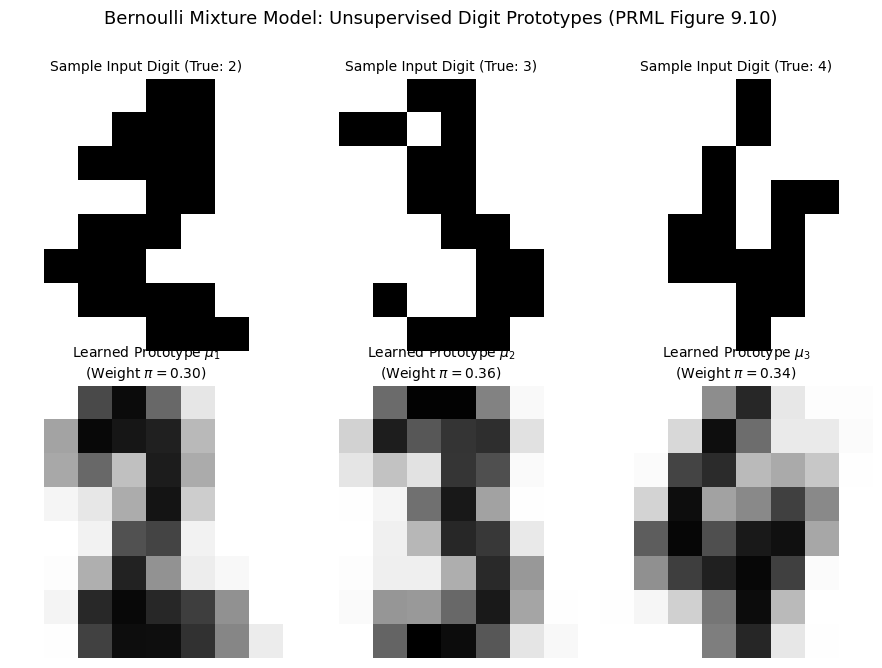

In [2]:
from sklearn.datasets import load_digits
from common.mixture_em_utils import BernoulliMixtureModel

# 8x8 手書き数字データ (Digits) から 2, 3, 4 の3文字を抽出
digits = load_digits()
mask = np.isin(digits.target, [2, 3, 4])
X_digits = digits.data[mask]
y_digits = digits.target[mask]

# 二値化 (閾値 0.5)
X_binary = (X_digits > 7.0).astype(float)
N_sub = len(X_binary)
print(f"Loaded {N_sub} binary digit images for classes 2, 3, and 4.")

# ベルヌーイ混合モデル (K=3) の学習
bmm = BernoulliMixtureModel(n_components=3, max_iter=40, random_state=42)
bmm.fit(X_binary)

# PRML Figure 9.10: 典型サンプルと学習されたプロトタイプ平均 μ_k の可視化
fig, axes = plt.subplots(2, 3, figsize=(9, 6.5))

# 上段: 入力サンプルの例
example_indices = [np.where(y_digits == cls)[0][0] for cls in [2, 3, 4]]
for col, idx in enumerate(example_indices):
    axes[0, col].imshow(X_binary[idx].reshape(8, 8), cmap='gray_r', interpolation='nearest')
    axes[0, col].set_title(f'Sample Input Digit (True: {y_digits[idx]})', fontsize=10)
    axes[0, col].axis('off')

# 下段: BMM により非教師あり学習された成分平均 μ_k (プロトタイプ)
for k in range(3):
    mu_img = bmm.means_[k].reshape(8, 8)
    axes[1, k].imshow(mu_img, cmap='gray_r', vmin=0, vmax=1, interpolation='nearest')
    axes[1, k].set_title(f'Learned Prototype $\mu_{k+1}$\n(Weight $\pi={bmm.weights_[k]:.2f}$)', fontsize=10)
    axes[1, k].axis('off')

plt.suptitle('Bernoulli Mixture Model: Unsupervised Digit Prototypes (PRML Figure 9.10)', fontsize=13, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig9_10_bernoulli_mixture_digits.png')
plt.show()